# EDA 7 v4 — Case-flow decompositions for Results Figure 4.6

This revision **removes the Kingston case** and aligns the alluvial/mirrored-flow diagrams with the chapter-wide
`flow_yee_palette_v2.py` colour grammar and adds **Westminster 019** as an
Inner-London, super-gentrification-associated example of the
`outflow-internal-majority` profile.

The outputs support two Results claims without interpreting their causes:

1. **Cascade-case heterogeneity and temporal change:** the same coarse
   `Cascade-led` label can be generated by inflow-driven, internal-outflow or
   external-outflow compositions, and some cases change to Counter-led by 2021.
2. **Comparison with Yee and Dennett subtypes:** Westminster 019 is included as
   a case-level illustration of the outflow-internal profile in which SupGen
   markers are concentrated. The subtype relationship itself remains quantified
   in Section 4.6 and Table 4.4.

The notebook produces:
- one compact four-case main-text composite for Figure 4.6;
- four fuller appendix sheets preserving the additional diagnostic cases.


In every panel:
- inflows enter on the left and outflows leave on the right;
- ribbon width is proportional to recorded person-moves;
- dark red / pale red show cascade-direction flows within London / crossing the London boundary;
- dark blue / pale blue show counter-direction flows within London / crossing the London boundary.

Purple is reserved for Yee and Dennett attribute labels elsewhere in the chapter and is therefore not used for flow arms.


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from matplotlib.patches import PathPatch
 
plt.rcParams['font.family'] = 'DejaVu Sans'

from pyprojroot import here

ROOT = here()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from flow_yee_palette_v2 import ALLUVIAL


In [2]:

ROOT       = here()
sys.path.insert(0, str(ROOT))

DATA_DIR   = ROOT / 'data'
OUT_DIR    = ROOT / 'outputs' / 'case_study' / 'figure_4_6'
NAT  = ROOT / 'outputs'/'msoa_cascade_national_frame_20260625.csv'
EDA4 = ROOT / 'outputs'/'eda4_results_for_phase3_20260626.csv'
LOOKUP = DATA_DIR / 'MSOA_2011_to_2021_lookup_for_identification.csv'
EXT_DECILE = 6                                   # synthetic external node sits at national D6
YL = 3.05

OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Chapter-wide colour grammar imported from flow_yee_palette_v2.py
C_IN = ALLUVIAL['cascade_in']
C_EX = ALLUVIAL['cascade_ex']
K_IN = ALLUVIAL['counter_in']
K_EX = ALLUVIAL['counter_ex']

BAR  = '#2f2f2f'
ZONE = '#f2f0ec'          # rest-of-England margin shading
BND  = '#8a8a8a'          # boundary dash colour


In [4]:
# ── x-geometry ──────────────────────────────────────────────────────────
X_EXT_L = -1.05   # external ribbons start here (left)
X_BND_L =  0.30   # London boundary, left
X_ML    =  3.30   # MSOA bar left edge
X_MR    =  3.90   # MSOA bar right edge
X_BND_R =  6.90   # London boundary, right
X_EXT_R =  8.25   # external ribbons end here (right)
 
INNER_LONDON = {
    'Camden','City of London','Greenwich','Hackney','Hammersmith and Fulham',
    'Haringey','Islington','Kensington and Chelsea','Lambeth','Lewisham',
    'Newham','Southwark','Tower Hamlets','Wandsworth','Westminster',
}

In [5]:
def _band(ax, x0, x1, lo, hi, color):
    ax.add_patch(mpatches.Rectangle((x0, lo), x1-x0, hi-lo,
                                    facecolor=color, edgecolor='none',
                                    alpha=0.92, zorder=3))

In [6]:
def _chevron(ax, xc, yc, h):
    """White right-pointing chevron centred at (xc, yc); h = band height."""
    s = min(h*0.55, 0.14)
    if s < 0.045: return
    w = s * 0.9
    verts = [(xc-w/2, yc+s), (xc+w/2, yc), (xc-w/2, yc-s),
             (xc-w/2+w*0.45, yc), (xc-w/2, yc+s)]
    ax.add_patch(PathPatch(Path(verts, closed=True), facecolor='white',
                           edgecolor='none', alpha=0.85, zorder=4))

In [7]:
def _lay(segs, gap, scale):
    hs = [(v/scale, c, n, x0, x1) for v, c, n, x0, x1 in segs]
    tot = sum(h for h, *_ in hs) + gap*(sum(1 for _, _, n, _, _ in hs if n) - 1)
    top = tot/2; out = []
    for i, (h, c, n, x0, x1) in enumerate(hs):
        if n and i > 0: top -= gap
        out.append((top-h, top, c, x0, x1)); top -= h
    return out

In [8]:
def arms_split(r, yr):
    d  = r['Wealth_Decile_National']
    ei, eo = r[f'Ext_Inflow_nat_{yr}'], r[f'Ext_Outflow_nat_{yr}']
    iw, op = r[f'Inflow_Wealthier_nat_{yr}'], r[f'Outflow_Poorer_nat_{yr}']
    ip, ow = r[f'Inflow_Poorer_nat_{yr}'],    r[f'Outflow_Wealthier_nat_{yr}']
    e_iw = ei if d < EXT_DECILE else 0; e_ip = ei if d > EXT_DECILE else 0
    e_ow = eo if d < EXT_DECILE else 0; e_op = eo if d > EXT_DECILE else 0
    return dict(iw=iw, op=op, ip=ip, ow=ow, iw_e=e_iw, op_e=e_op, ip_e=e_ip, ow_e=e_ow,
                iw_i=iw-e_iw, op_i=op-e_op, ip_i=ip-e_ip, ow_i=ow-e_ow)

In [9]:
def panel(ax, r, yr, scale, title, dom_lon, show_headers=True):
    a = arms_split(r, yr); gap = 0.30
 
    # background: rest-of-England margins + boundary dashes
    ax.add_patch(mpatches.Rectangle((X_EXT_L-0.55, -YL), X_BND_L-(X_EXT_L-0.55), 2*YL,
                                    facecolor=ZONE, edgecolor='none', zorder=0))
    ax.add_patch(mpatches.Rectangle((X_BND_R, -YL), (X_EXT_R+0.55)-X_BND_R, 2*YL,
                                    facecolor=ZONE, edgecolor='none', zorder=0))
    for xb in (X_BND_L, X_BND_R):
        ax.plot([xb, xb], [-YL*0.88, YL*0.80], ls=(0,(4,3)), lw=0.9, color=BND, zorder=1)
    ax.text(X_BND_L, -YL*0.96, 'London boundary', ha='center', va='top',
            fontsize=5.8, color=BND)
    ax.text(X_BND_R, -YL*0.96, 'London boundary', ha='center', va='top',
            fontsize=5.8, color=BND)
    ax.text((X_EXT_L-0.55+X_BND_L)/2, -YL*0.80, 'rest of\nEngland', ha='center',
            va='center', fontsize=5.8, color='#9a9a9a', style='italic')
    ax.text((X_BND_R+X_EXT_R+0.55)/2, -YL*0.80, 'rest of\nEngland', ha='center',
            va='center', fontsize=5.8, color='#9a9a9a', style='italic')
 
    # segments now carry their own x-extent: internal stops at the boundary,
    # external crosses it
    Lsegs = [(a['iw_i'], C_IN, True,  X_BND_L, X_ML),
             (a['iw_e'], C_EX, False, X_EXT_L, X_ML),
             (a['ip_i'], K_IN, True,  X_BND_L, X_ML),
             (a['ip_e'], K_EX, False, X_EXT_L, X_ML)]
    Rsegs = [(a['ow_i'], K_IN, True,  X_MR, X_BND_R),
             (a['ow_e'], K_EX, False, X_MR, X_EXT_R),
             (a['op_i'], C_IN, True,  X_MR, X_BND_R),
             (a['op_e'], C_EX, False, X_MR, X_EXT_R)]
    L, R = _lay(Lsegs, gap, scale), _lay(Rsegs, gap, scale)
 
    for lo, hi, c, x0, x1 in L:
        _band(ax, x0, x1, lo, hi, c)
        _chevron(ax, X_ML-0.55, (lo+hi)/2, hi-lo)          # arrows into the bar
    for lo, hi, c, x0, x1 in R:
        _band(ax, x0, x1, lo, hi, c)
        _chevron(ax, x1-0.45, (lo+hi)/2, hi-lo)            # arrows exiting
 
    bar_lo, bar_hi = min(L[-1][0], R[-1][0]), max(L[0][1], R[0][1])
    ax.add_patch(mpatches.Rectangle((X_ML, bar_lo), X_MR-X_ML, bar_hi-bar_lo,
                                    facecolor=BAR, edgecolor='none', zorder=5))
 
    # arm labels + counts, anchored at the OUTER end of each arm
    iw_c=(L[0][0]+L[1][1])/2; ip_c=(L[2][0]+L[3][1])/2
    ow_c=(R[0][0]+R[1][1])/2; op_c=(R[2][0]+R[3][1])/2
    def lab(x, y, name, tot, ext, c, ha):
        if tot/scale < 0.03: return
        ax.text(x, y+0.085, name, ha=ha, va='bottom', fontsize=6.4,
                color=c, fontweight='bold')
        ax.text(x, y-0.075, f'{int(tot)}'+(f' (ext {int(ext)})' if ext > 0.5 else ''),
                ha=ha, va='top', fontsize=6.8, color=c)
    lab(X_EXT_L-0.68, iw_c, 'from wealthier', a['iw'], a['iw_e'], C_IN, 'right')
    lab(X_EXT_L-0.68, ip_c, 'from poorer',    a['ip'], a['ip_e'], K_IN, 'right')
    lab(X_EXT_R+0.68, ow_c, 'to wealthier',   a['ow'], a['ow_e'], K_IN, 'left')
    lab(X_EXT_R+0.68, op_c, 'to poorer',      a['op'], a['op_e'], C_IN, 'left')
 
    # direction headers, drawn on the plot itself
    if show_headers:
        ax.text((X_EXT_L+X_ML)/2, YL*0.90, 'I N F L O W S  \u25b6',
                ha='center', va='center', fontsize=7.6, color='#555',
                fontweight='bold')
        ax.text((X_MR+X_EXT_R)/2, YL*0.90, '\u25b6  O U T F L O W S',
                ha='center', va='center', fontsize=7.6, color='#555',
                fontweight='bold')
 
    # geography chip: ring + national decile
    ring = 'Inner' if r['ladnm'] in INNER_LONDON else 'Outer'
    ax.text(0.99, 0.985, f"{ring} London \u00b7 nat D{int(r['Wealth_Decile_National'])}",
            transform=ax.transAxes, ha='right', va='top', fontsize=6.6,
            color='#444',
            bbox=dict(boxstyle='round,pad=0.32', fc='white', ec='#cfcfcf', lw=0.7))
 
    casc, cnt = a['iw']+a['op'], a['ip']+a['ow']; dom = casc/(casc+cnt)
    infl = a['iw']/(a['iw']+a['op']) if (a['iw']+a['op']) else np.nan
    ext_sh = (a['iw_e']+a['ip_e']+a['ow_e']+a['op_e'])/(casc+cnt) if (casc+cnt) else 0
    ax.text(0.5, -0.045, f'dominance(nat) {dom:.2f}   inflow share {infl:.2f}   '
            f'external(cross-decile) {ext_sh:.0%}   \u00b7   dominance(London) {dom_lon:.2f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=8,
            color=C_IN if dom >= 0.5 else K_IN, fontweight='bold')
    ax.text(0.5, 1.0, title, transform=ax.transAxes, ha='center', va='bottom',
            fontsize=10, fontweight='bold')
    ax.set_xlim(X_EXT_L-2.55, X_EXT_R+2.55); ax.set_ylim(-YL, YL)
    ax.set_axis_off()

In [10]:
nat = pd.read_csv(NAT)
e4 = pd.read_csv(EDA4)

domA = lambda c, yr: e4.loc[e4['msoa11cd'].eq(c), f'Dom_A_{yr}'].iloc[0]
row  = lambda c: nat.loc[nat['msoa11cd'].eq(c)].iloc[0]

# Resolve named cases reproducibly instead of hard-coding an uncertain code.
lookup = pd.read_csv(LOOKUP, encoding='utf-8-sig')
code_candidates = ['MSOA11CD', 'msoa11cd']
name_candidates = ['MSOA11NM', 'MSOA11HCLNM', 'msoa11nm', 'msoa11hclnm']
code_col = next((c for c in code_candidates if c in lookup.columns), None)
name_col = next((c for c in name_candidates if c in lookup.columns), None)
if code_col is None or name_col is None:
    raise KeyError(f'Could not identify MSOA code/name columns in {LOOKUP.name}: {list(lookup.columns)}')

def resolve_msoa(name):
    hit = lookup.loc[lookup[name_col].astype(str).str.casefold().eq(name.casefold()), code_col].dropna().unique()
    if len(hit) != 1:
        raise ValueError(f'Expected exactly one code for {name!r}; found {hit.tolist()}')
    return hit[0]

WESTMINSTER_019 = resolve_msoa('Westminster 019')
print('Westminster 019:', WESTMINSTER_019)


Westminster 019: E02000978


In [11]:
def figscale(cases):
    m = 0
    for c, _ in cases:
        r = row(c)
        for yr in ['11','21']:
            a = arms_split(r, yr); m = max(m, a['iw']+a['ip'], a['ow']+a['op'])
    return m/3.0

In [12]:
LEG = [
    mpatches.Patch(color=C_IN, label='Cascade direction · within London'),
    mpatches.Patch(color=C_EX, label='Cascade direction · crossing London boundary'),
    mpatches.Patch(color=K_IN, label='Counter direction · within London'),
    mpatches.Patch(color=K_EX, label='Counter direction · crossing London boundary'),
]


In [13]:
# def build(title, cases, fname, caption):
#     sc = figscale(cases); nr = len(cases)
#     fig, axes = plt.subplots(nr, 2, figsize=(13, 3.0*nr+1.6), squeeze=False)
#     for i, (c, n) in enumerate(cases):
#         panel(axes[i,0], row(c), '11', sc, f'{n}  ·  2011', domA(c,'11'))
#         panel(axes[i,1], row(c), '21', sc, f'{n}  ·  2021', domA(c,'21'))
#     fig.suptitle(title, fontsize=13.5, fontweight='bold', y=0.995)
#     fig.legend(handles=LEG, loc='lower center', ncol=2, frameon=False, fontsize=8.4, bbox_to_anchor=(0.5,0.004))
#     fig.text(0.5, 0.055, 'Inflows enter on the left, outflows exit on the right.  ' + caption,
#              ha='center', va='bottom', fontsize=8.2, style='italic', color='#333', wrap=True)
#     plt.tight_layout(rect=[0,0.085,1,0.97]); plt.savefig(OUT_DIR / fname, dpi=130, bbox_inches='tight'); plt.show()

In [14]:
def build(title, cases, fname, caption='', figsize_per_row=3.25, dpi=180):
    sc = figscale(cases)
    nr = len(cases)
    fig, axes = plt.subplots(nr, 2, figsize=(14, figsize_per_row * nr + 1.5), squeeze=False)
    for i, (code, name) in enumerate(cases):
        panel(axes[i, 0], row(code), '11', sc, f'{name}  ·  2011', domA(code, '11'), show_headers=(i == 0))
        panel(axes[i, 1], row(code), '21', sc, f'{name}  ·  2021', domA(code, '21'), show_headers=(i == 0))

    fig.suptitle(title, fontsize=13.5, fontweight='bold', y=0.995)
    fig.legend(handles=LEG, loc='lower center', ncol=4, frameon=False,
               fontsize=8.2, bbox_to_anchor=(0.5, 0.006))
    if caption:
        fig.text(0.5, 0.047, caption, ha='center', va='bottom', fontsize=8.1,
                 style='italic', color='#333333', wrap=True)
    plt.tight_layout(rect=[0, 0.072 if caption else 0.04, 1, 0.975])
    out = OUT_DIR / fname
    plt.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f'Saved {out}')
    plt.show()


In [15]:
def figscale(cases):
    m = 0
    for c, _ in cases:
        r = row(c)
        for yr in ['11','21']:
            a = arms_split(r, yr); m = max(m, a['iw']+a['ip'], a['ow']+a['op'])
    return m/3.0

Saved /Users/xing/Desktop/CASA/dissertation/outputs/case_study/figure_4_6/fig_4_6_selected_flow_decompositions.png


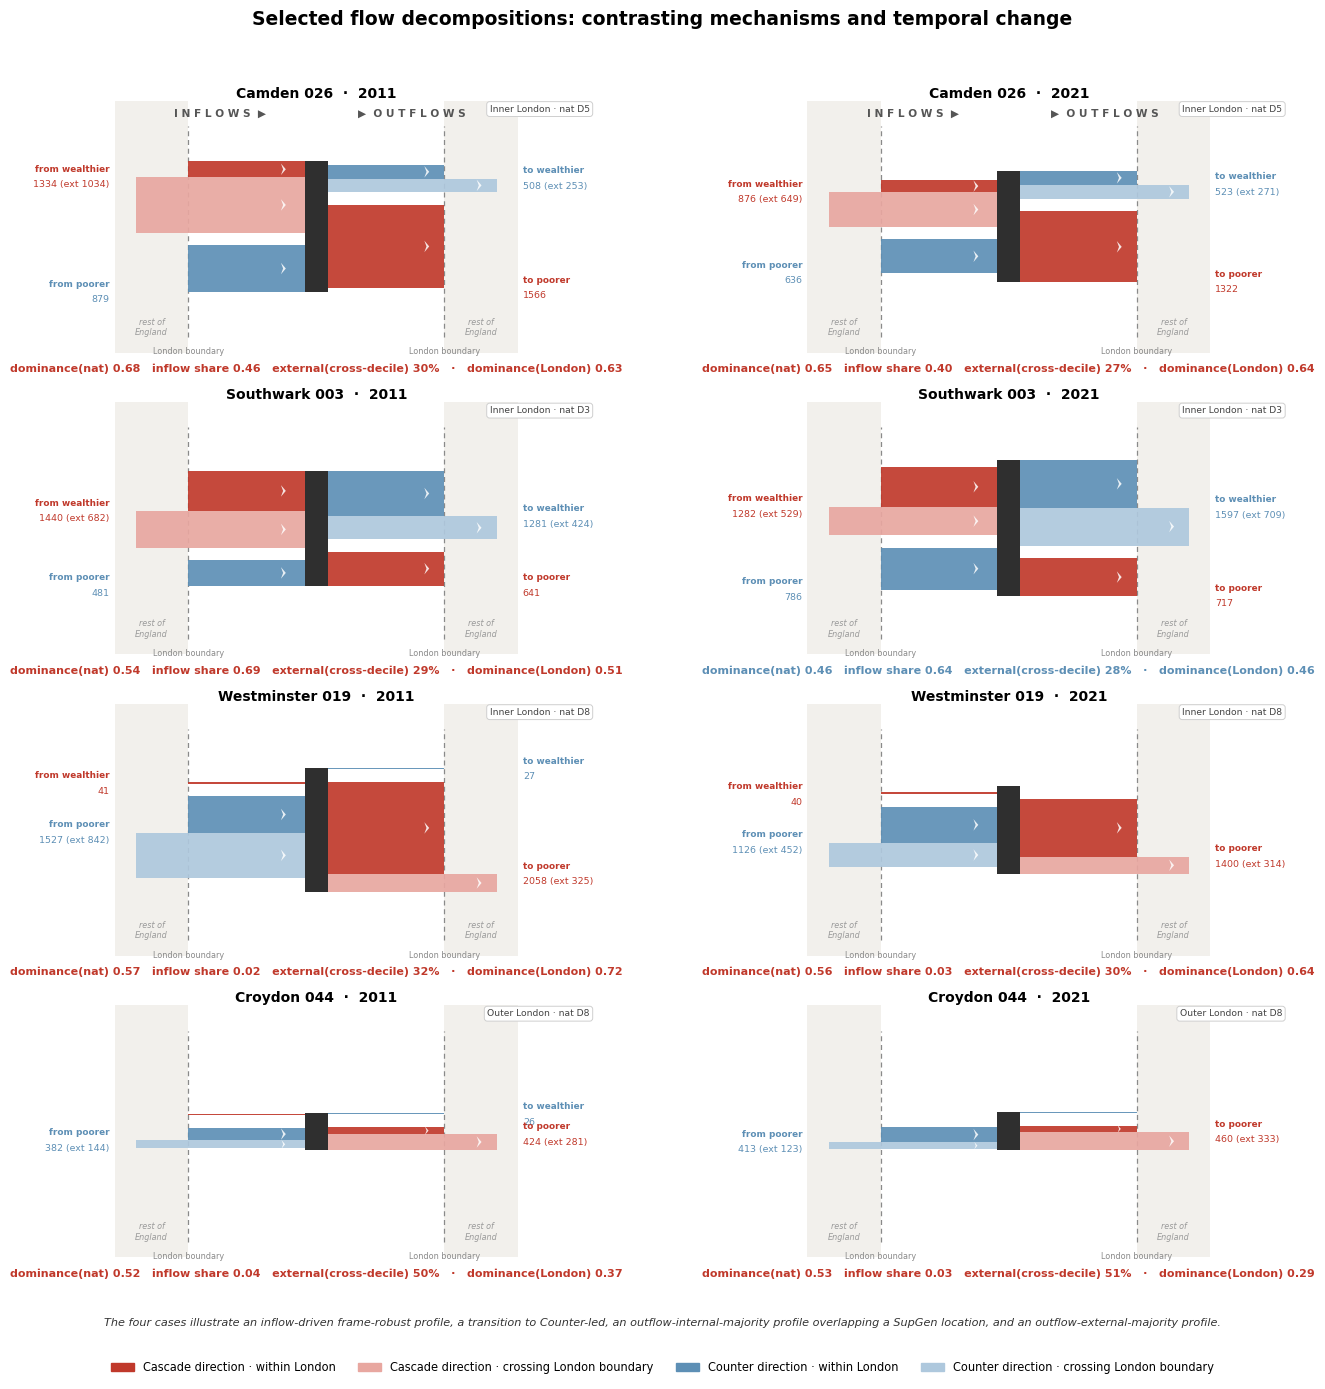

Saved /Users/xing/Desktop/CASA/dissertation/outputs/case_study/figure_4_6/appendix_case_A_inflow_driven_frame_robust.png


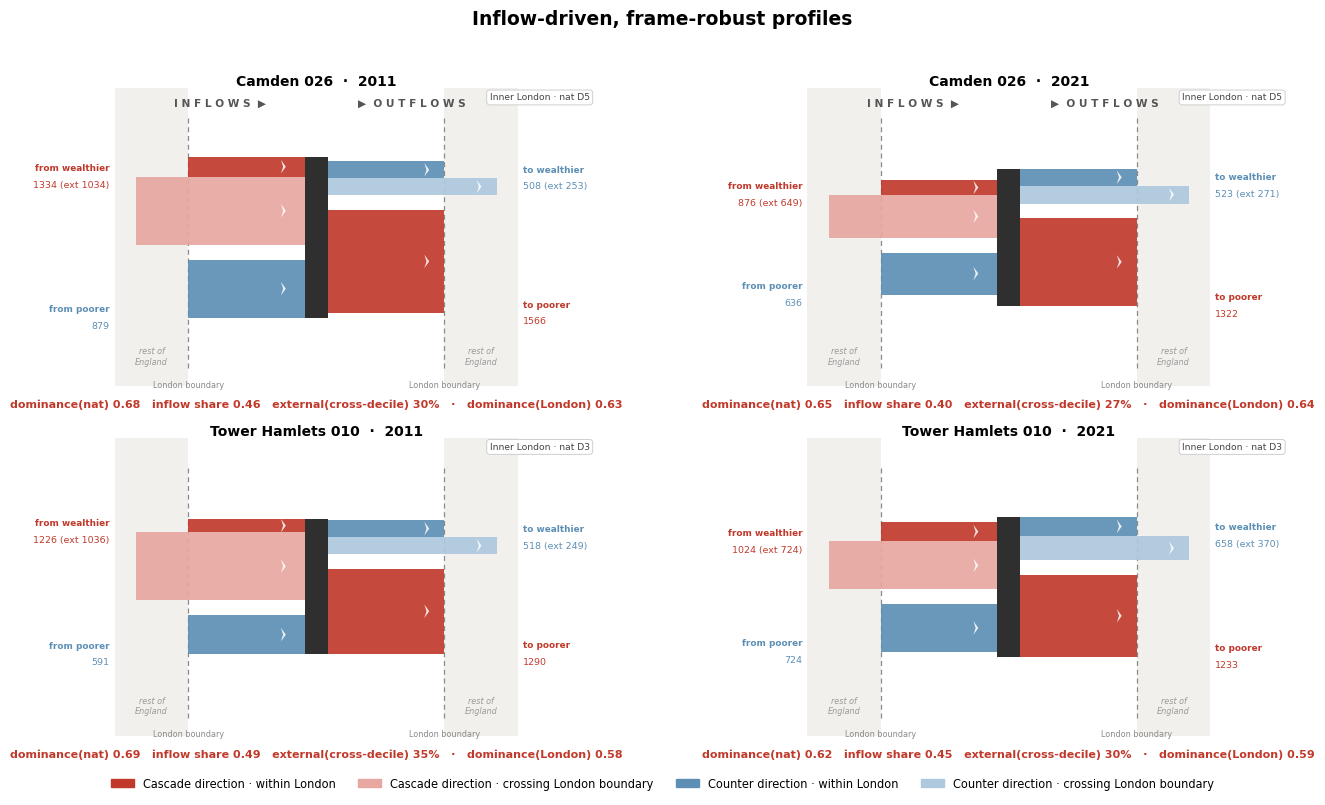

Saved /Users/xing/Desktop/CASA/dissertation/outputs/case_study/figure_4_6/appendix_case_B_temporal_change_to_counter.png


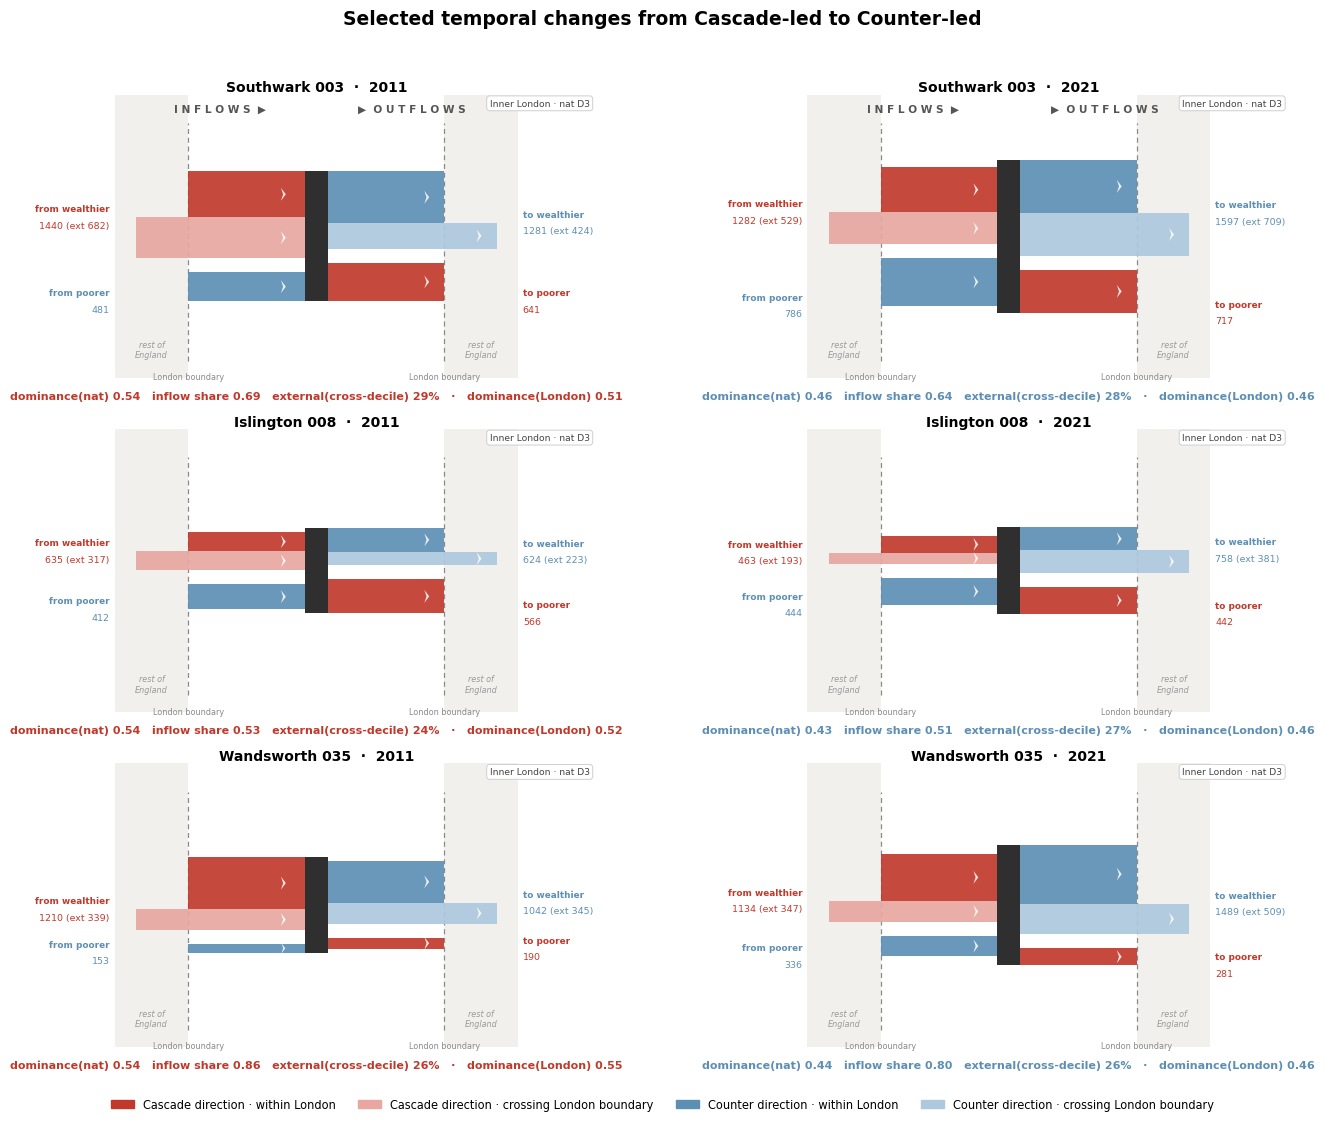

Saved /Users/xing/Desktop/CASA/dissertation/outputs/case_study/figure_4_6/appendix_case_C_outflow_internal_heterogeneity.png


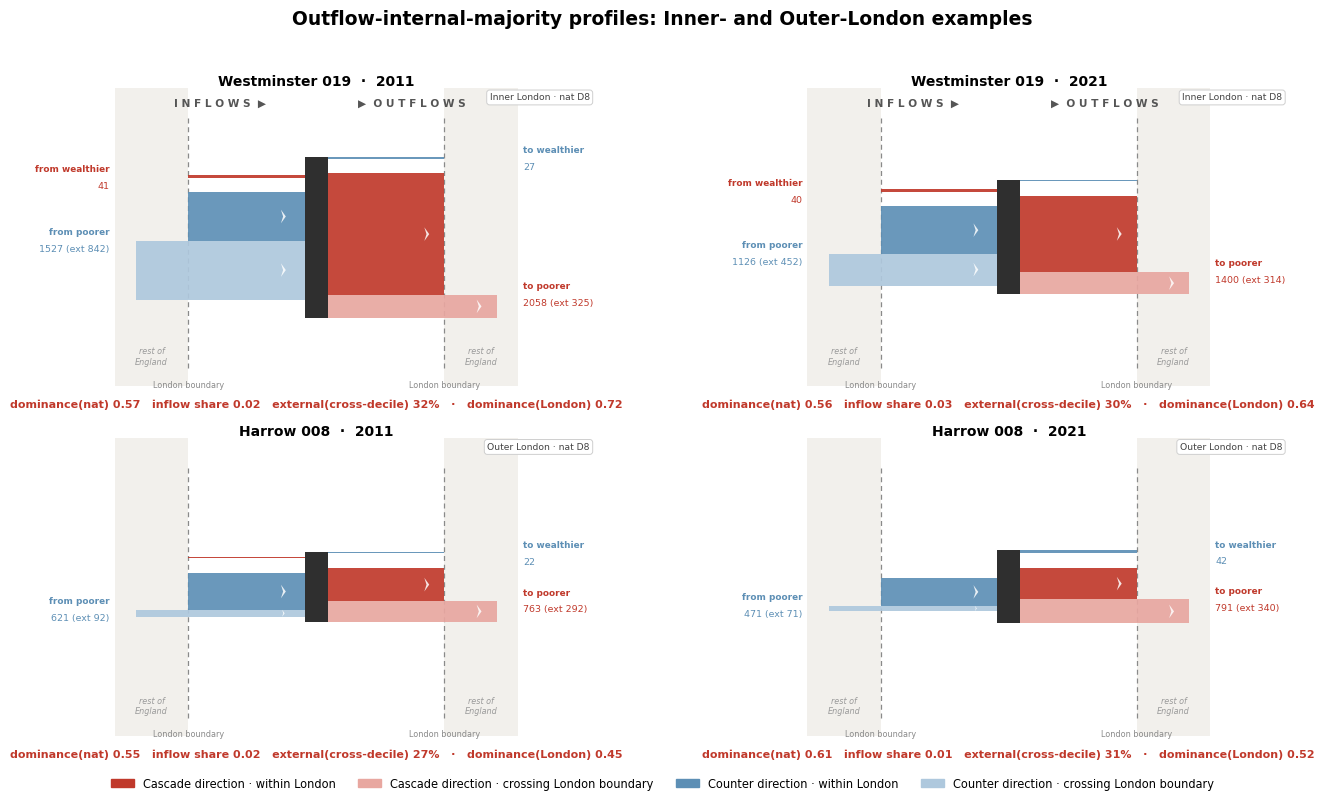

Saved /Users/xing/Desktop/CASA/dissertation/outputs/case_study/figure_4_6/appendix_case_D_outflow_external_majority.png


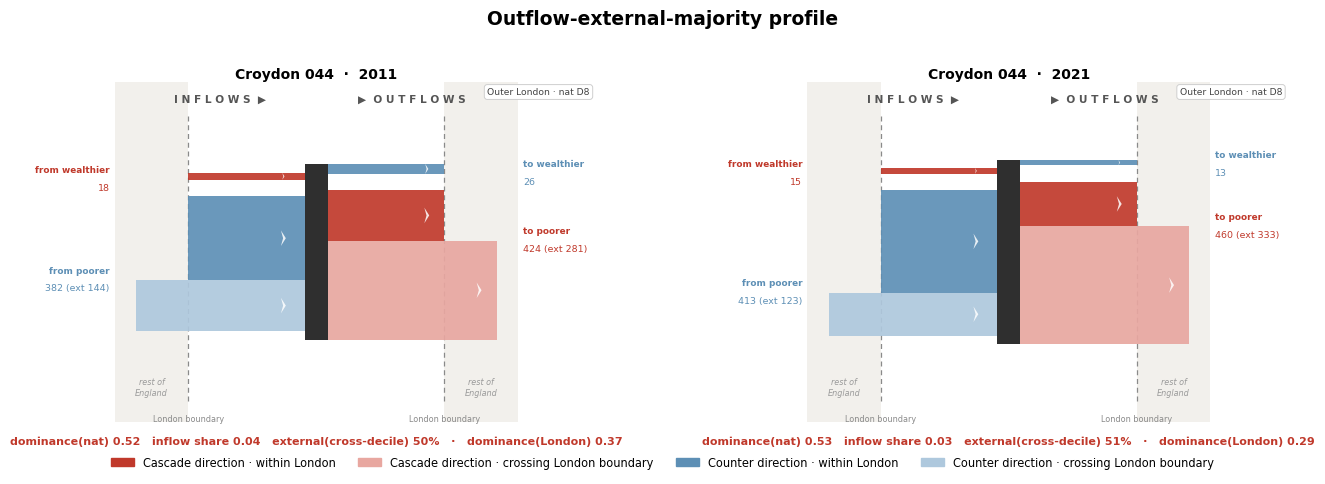

In [16]:
# ── case rosters ───────────────────────────────────────────────────────────
CASES_INFLOW = [
    ('E02000191', 'Camden 026'),
    ('E02000873', 'Tower Hamlets 010'),
]

CASES_TEMPORAL = [
    ('E02000809', 'Southwark 003'),
    ('E02000561', 'Islington 008'),
    ('E02000957', 'Wandsworth 035'),
]

# The pair deliberately shows heterogeneity within outflow-internal-majority:
# Westminster is an Inner-London SupGen-associated case; Harrow is an outer-London diagnostic case.
CASES_OUTFLOW_INTERNAL = [
    (WESTMINSTER_019, 'Westminster 019'),
    ('E02000440', 'Harrow 008'),
]

CASES_OUTFLOW_EXTERNAL = [
    ('E02000237', 'Croydon 044'),
]

# Main-text Figure 4.6: one representative case for each empirical pattern.
CASES_MAIN = [
    ('E02000191', 'Camden 026'),                 # inflow-driven, frame-robust
    ('E02000809', 'Southwark 003'),              # temporal change to Counter-led
    (WESTMINSTER_019, 'Westminster 019'),        # outflow-internal + SupGen overlap
    ('E02000237', 'Croydon 044'),                # outflow-external-majority
]

build(
    'Selected flow decompositions: contrasting mechanisms and temporal change',
    CASES_MAIN,
    'fig_4_6_selected_flow_decompositions.png',
    caption=(
        'The four cases illustrate an inflow-driven frame-robust profile, a transition to Counter-led, '
        'an outflow-internal-majority profile overlapping a SupGen location, and an outflow-external-majority profile.'
    ),
    figsize_per_row=3.10,
)

# Fuller appendix sheets.
build('Inflow-driven, frame-robust profiles', CASES_INFLOW,
      'appendix_case_A_inflow_driven_frame_robust.png')

build('Selected temporal changes from Cascade-led to Counter-led', CASES_TEMPORAL,
      'appendix_case_B_temporal_change_to_counter.png')

build('Outflow-internal-majority profiles: Inner- and Outer-London examples',
      CASES_OUTFLOW_INTERNAL,
      'appendix_case_C_outflow_internal_heterogeneity.png')

build('Outflow-external-majority profile', CASES_OUTFLOW_EXTERNAL,
      'appendix_case_D_outflow_external_majority.png')
